# Zebrafish: Supplementary Figures S31–S38

Start with the aligned zebrafish cells and trained model. This notebook simulates
the populations, calculates the downstream quantities, and draws S31–S38 in
order. Each plotting step uses the results named immediately above it.

Run the notebook after [installing CytoBridge](../../installation.md). A CUDA
GPU is recommended for the simulations. The default run uses the supplied
model. The training cell below shows how to fit a new model from the aligned
data. S36 has a separate option to train its four comparison models.

## 1. Data and output folders

The download contains `aligned.h5ad` with expression PCs, aligned spatial
coordinates, time labels, and cell types. It also supplies the dynamical model,
edge predictor, and cell-type classifiers. Preprocessing is already complete
for this input. Use a new `run` folder when repeating the notebook.

In [1]:
from pathlib import Path
import os
import subprocess
import sys

import pandas as pd
import torch
from IPython.display import Image, display
import CytoBridge as cb

project = Path(os.environ.get("CYTOBRIDGE_PROJECT_DIR", ".")).resolve()
code_dir = Path(os.environ.get("CYTOBRIDGE_SOURCE_DIR", Path(cb.__file__).resolve().parents[1]))
data = project / "data/zebrafish"
run = project / "outputs/zebrafish_s31_s38"
model_dir = data / "model"
device = "cuda:0" if torch.cuda.is_available() else "cpu"
train_model = False
retrain_loss_models = False

required = ["aligned.h5ad", "model/config.yaml", "edge_classifier/zebrafish_edge_model.pt",
            "edge_classifier/zebrafish_edge_model.pt.meta.json",
            "classifier_cache/classifier_resmlp_25f65c49dc60ea4c.pt",
            "paper_classifier/classifier_resmlp_0adc1c3a0170a81e.pt"]
if any(not (data / name).is_file() for name in required):
    cb.datasets.download("zebrafish", destination=project, kind="analysis")
missing = [name for name in required if not (data / name).is_file()]
if missing:
    raise FileNotFoundError(f"Download the zebrafish analysis files before continuing: {missing}")
run.mkdir(parents=True, exist_ok=False)
(run / "logs").mkdir()

def run_command(arguments, log_name):
    log = run / "logs" / f"{log_name}.log"
    with log.open("w") as stream:
        completed = subprocess.run([str(value) for value in arguments], cwd=code_dir,
                                   stdout=stream, stderr=subprocess.STDOUT)
    if completed.returncode:
        raise RuntimeError(f"Calculation failed. See {log}")

def show_figures(paths):
    for path in paths:
        if Path(path).suffix == ".png":
            display(Image(filename=str(path)))

## 2. Use the supplied model or train a new one

Leave `train_model = False` to use the downloaded model. Set it to `True` to
train from `aligned.h5ad` with the supplied configuration and edge predictor.
`cb.tl.fit` fits the dynamical model. It does not repeat preprocessing here.
The following analyses use `model_dir`, including when it points to the
new model. S36 trains its comparison models separately.

In [2]:
if train_model:
    model_dir = run / "trained_model"
    trained = cb.tl.fit(
        str(data / "aligned.h5ad"), config=str(data / "model/config.yaml"),
        device=device, time_key="time_point_processed", obsm_key="X_latent",
        spatial_key="spatial_aligned",
        edge_predictor_path=str(data / "edge_classifier/zebrafish_edge_model.pt"),
        ckpt_dir=model_dir, evaluate_after_training=False,
    )
model_dir

PosixPath('data/zebrafish/model')

## S31–S32. Populations and growth

S31 propagates the observed time-zero cells continuously to time four, with a
fixed population size. S32 evaluates the learned growth field on the observed
cells at each measured stage.

The analysis program calls `cb.tl.run_interpolation_workflow` to simulate
states and assign cell types, then `cb.tl.evaluate_growth_by_timepoint` to
calculate growth. Its `s22` stage produces the states for S31. The `growth`
stage writes `growth_per_cell.csv`. `--calculate-only` saves these numerical
outputs without drawing additional figures.

In [3]:
model_results = run / "model_analysis"
run_command([
    sys.executable, code_dir / "scripts/run_zebrafish_paper_downstream.py",
    "--aligned-h5ad", data / "aligned.h5ad", "--model-dir", model_dir,
    "--output-dir", model_results, "--shared-cache-dir", run / "classifier_cache",
    "--stage", "s22,growth", "--calculate-only", "--video-formats", "none",
    "--device", device,
], "populations_and_growth")

growth = pd.read_csv(model_results / "growth/growth_per_cell.csv")
growth.head()

,time,time_key,cell_index,x,y,growth,celltype
0,0.0,0.0,0,-0.966541,4.046007,0.194854,EVL
1,0.0,0.0,1,-0.109008,4.021175,0.189216,EVL
2,0.0,0.0,2,-0.137154,3.970739,0.307365,EVL
3,0.0,0.0,3,0.136774,3.870492,0.442672,EVL
4,0.0,0.0,4,0.041672,3.723786,0.421275,"Presumptive Mesoderm, Presumptive Ectoderm"


The next call reads the new state arrays in
`model_analysis/s22/observed_reference_states` and
`model_analysis/s22/global_t0_fixed_population_states`, together with `growth`'s
CSV. It arranges the populations for S31 and scales growth using each stage's
5th and 95th percentiles for S32. The plotted arrays, raw values and scaling
quantiles are saved beside the PDF/PNG files.

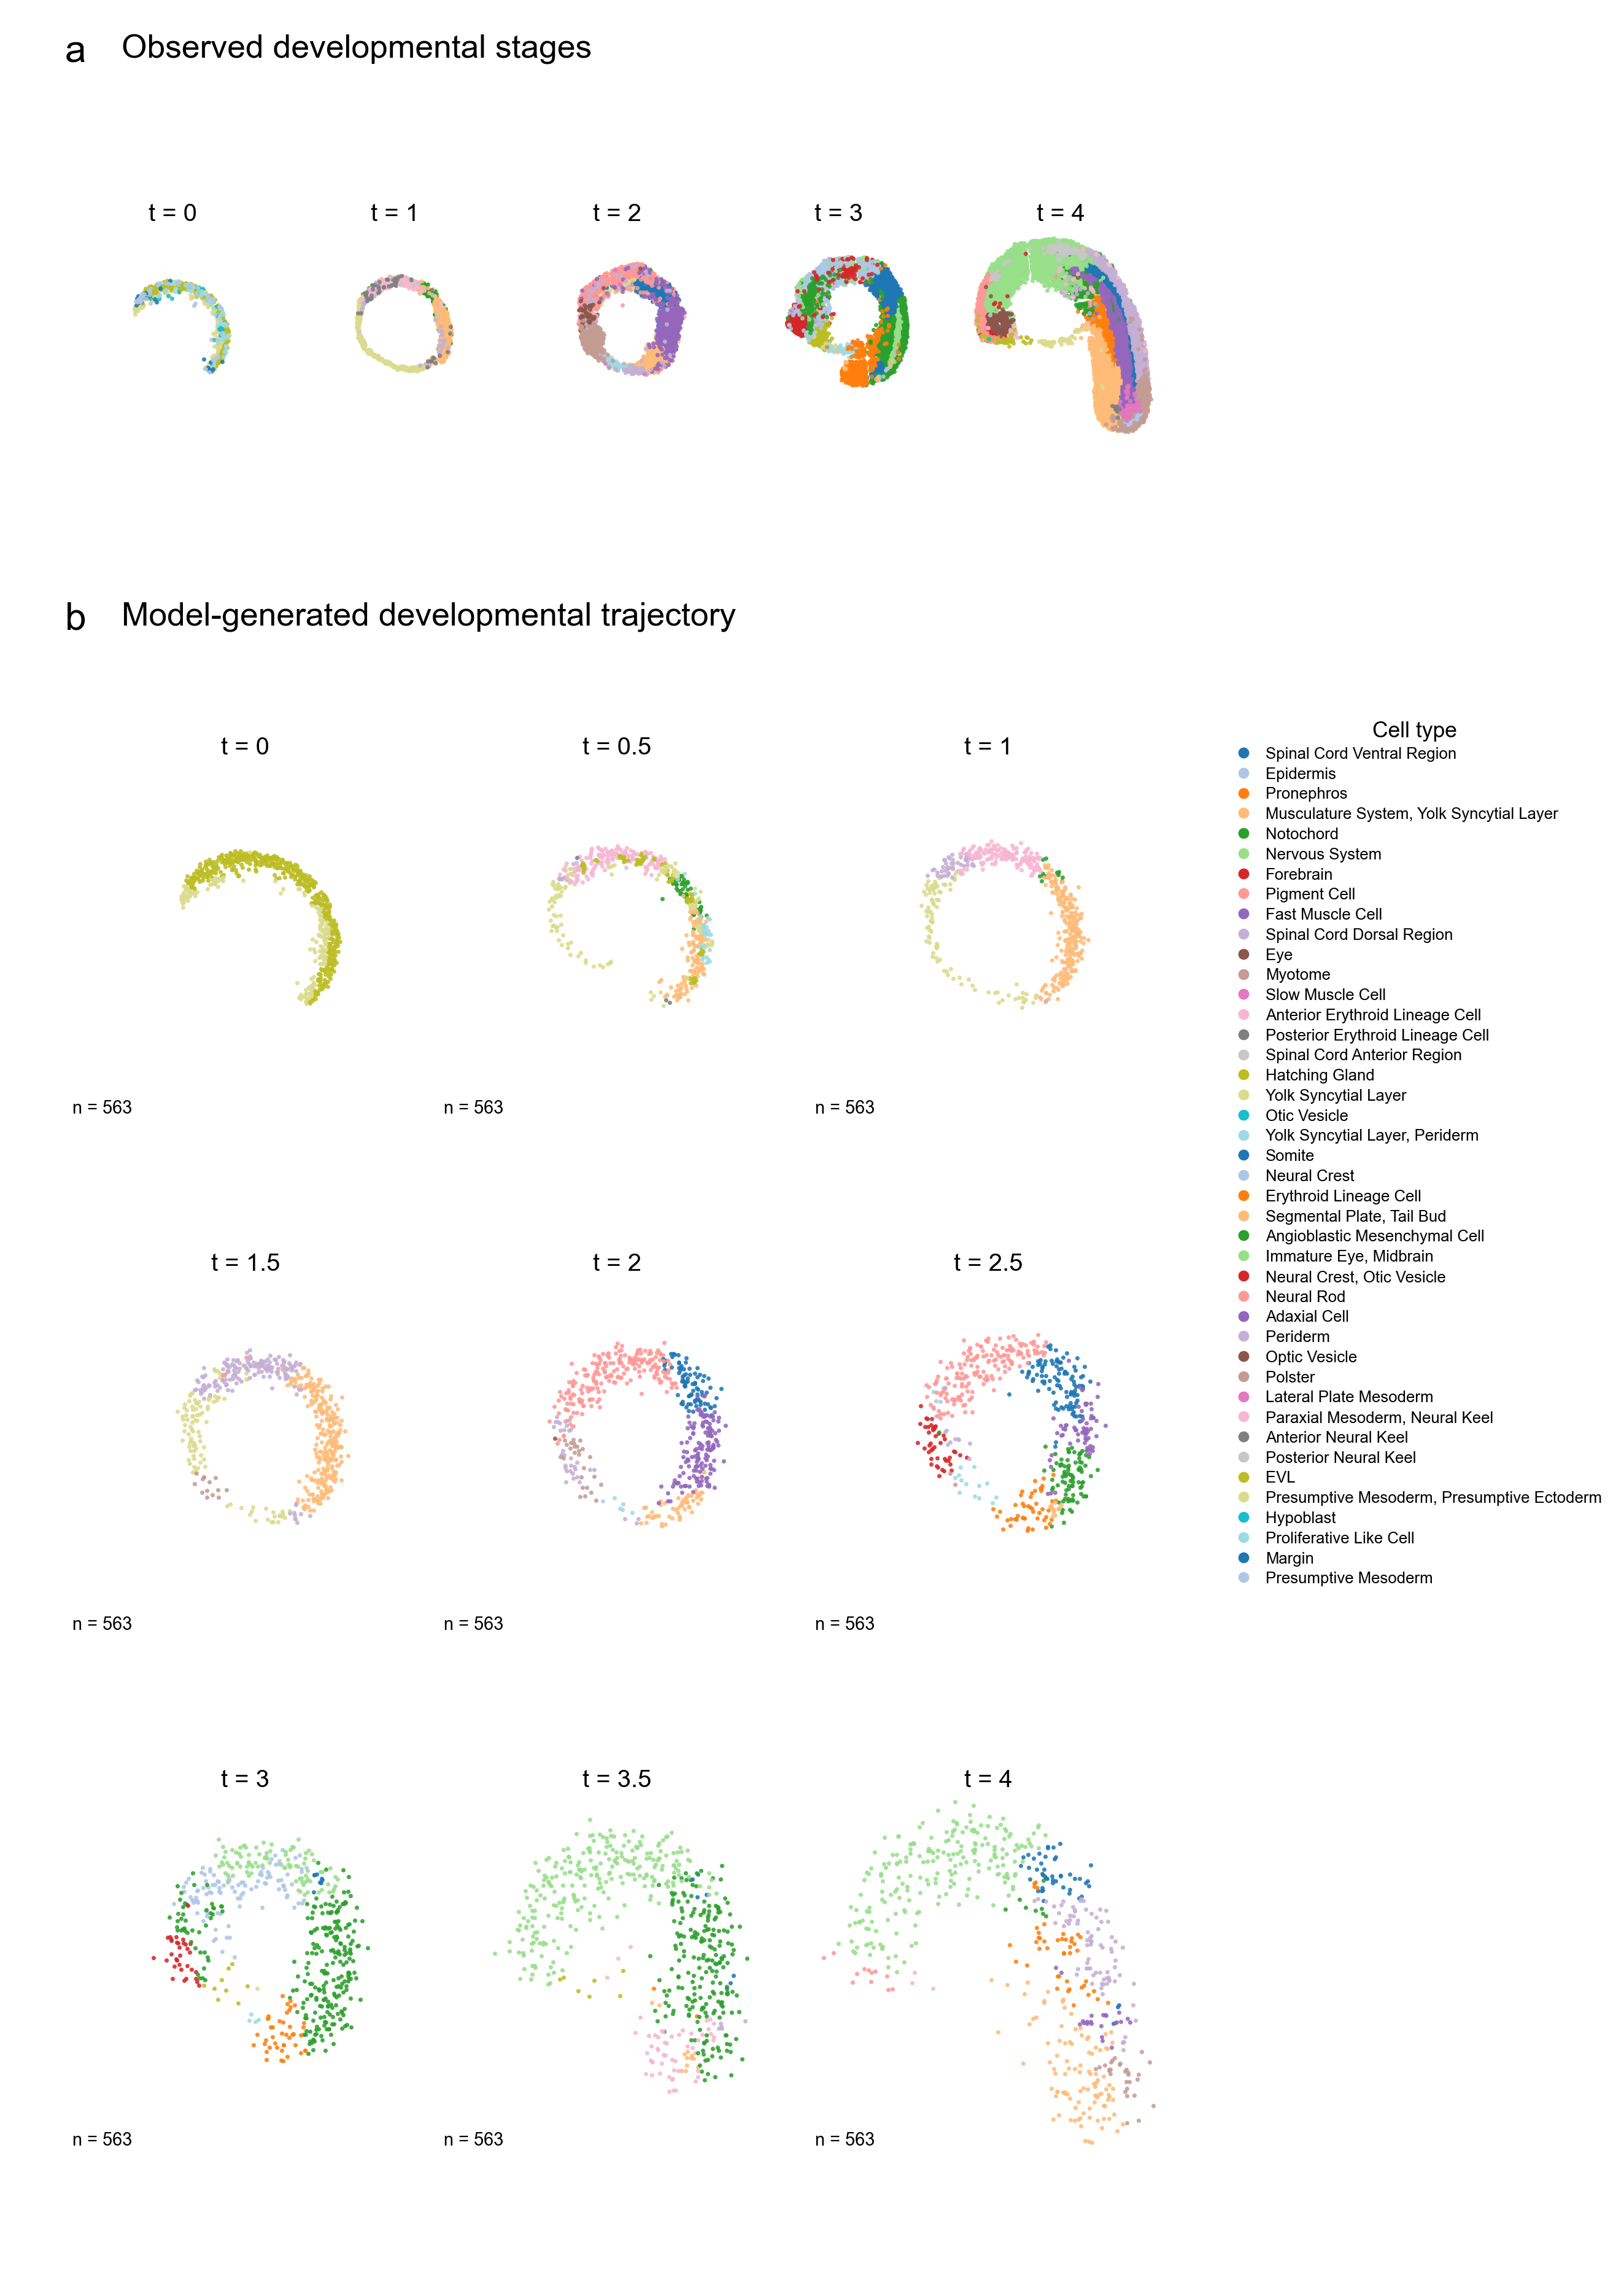

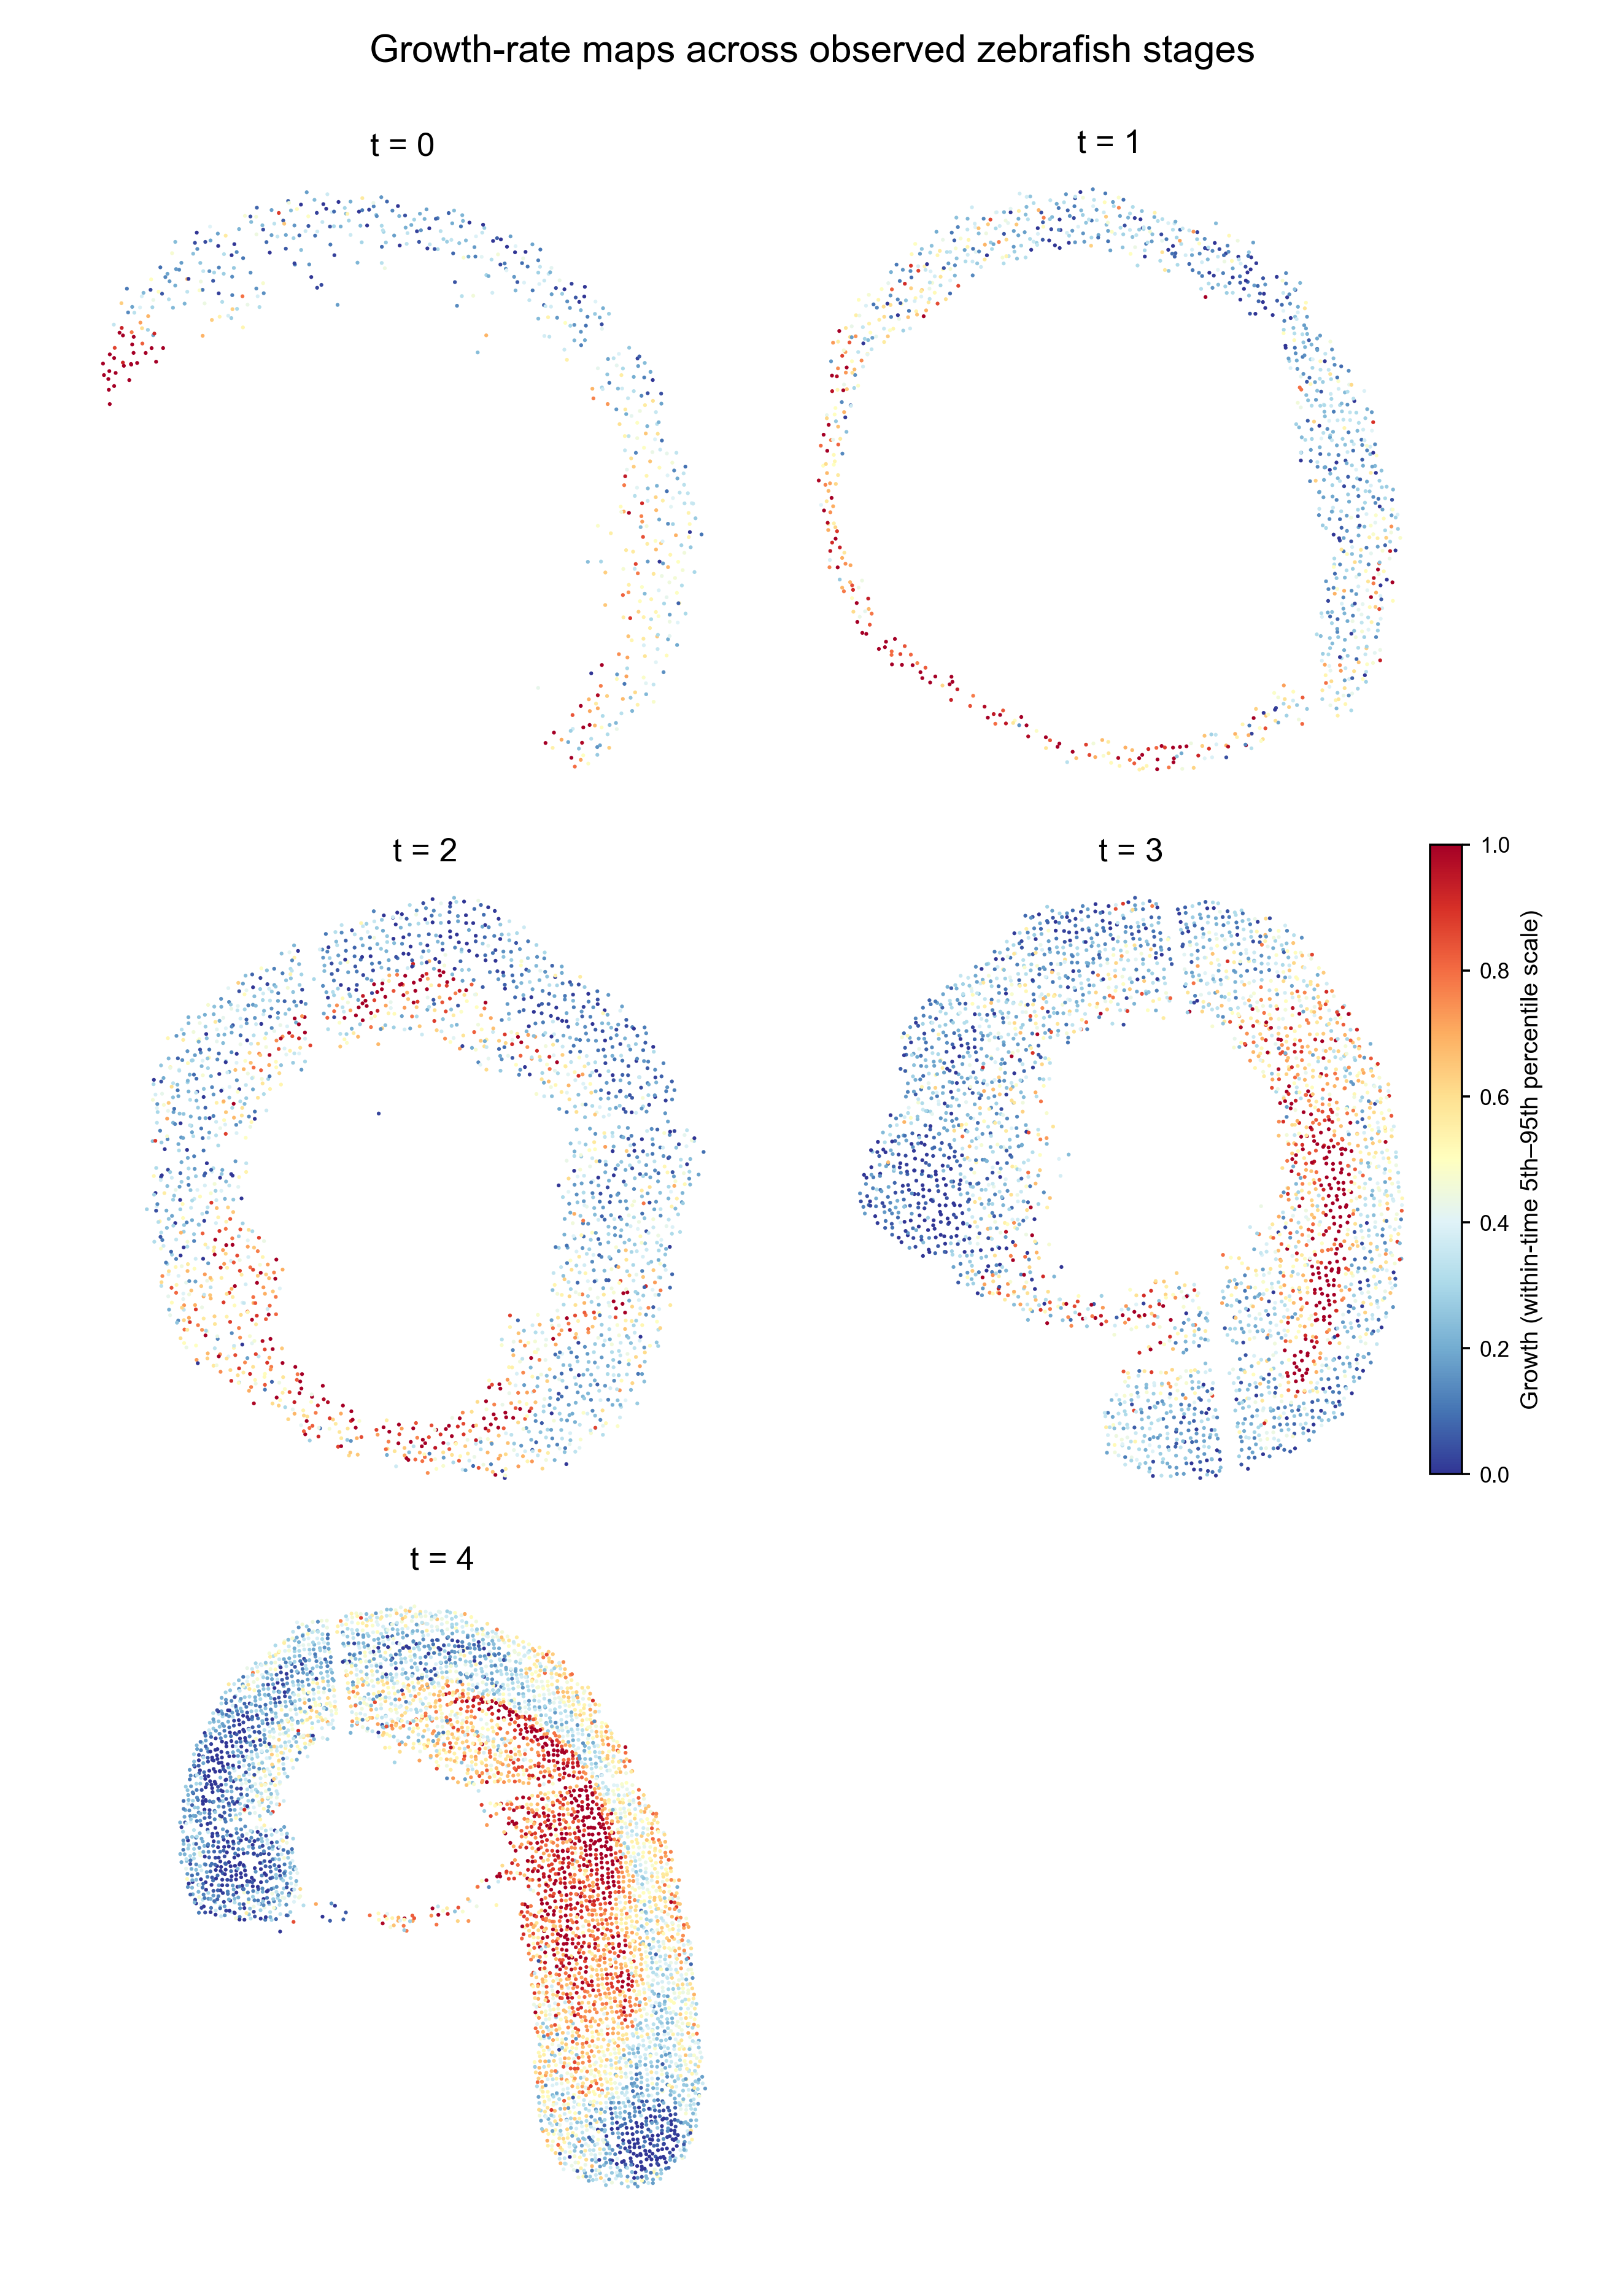

In [4]:
from reproduction.zebrafish.plot_population_growth import draw as plot_populations_and_growth

population_figures = plot_populations_and_growth(model_results, data / "aligned.h5ad", run / "s31_s32")
show_figures(population_figures)

## S33–S34. Virtual YSL and EVL removal

Compare the same time-zero population with all cells, without YSL cells, and
without EVL cells. Each seed uses `cb.tl.run_virtual_cell_type_ablation` to
propagate all three conditions with growth and diffusion, then calculates
spatial distances and centroid shifts from the paired baseline.

The five runs below use seeds 42–46. Each writes its state arrays to
`experiment/trajectories` and its distances to `experiment/ablation_metrics.csv`.
For these removals, the YSL-lineage analysis and daughter-cell perturbations,
the learned edge predictor is applied within the observed expression-state
range, as in the paper analysis.

In [5]:
from reproduction.zebrafish.virtual_removal import run as simulate_removal

seeds = [42, 43, 44, 45, 46]
removal_runs = []
for seed in seeds:
    folder = run / "removal" / f"seed_{seed}"
    simulate_removal(data, folder, seed=seed, device=device, model_dir=model_dir)
    removal_runs.append(folder)

S33 shows seed 42 at the five integer times. Cell types are assigned to those
simulated states with the supplied classifier. S34 shows its endpoint spatial
populations, mean W1 with standard errors across the five runs, and mean centroid
shifts with 95% t intervals. `collect_metrics` calculates these summaries from
the new run folders. `draw` uses the same folders for the spatial panels.

,variant,mean,sem,ci95_low,ci95_high
0,remove_EVL,0.174494,0.025503,0.103688,0.245301
1,remove_YSL,0.079715,0.024151,0.012660,0.146770


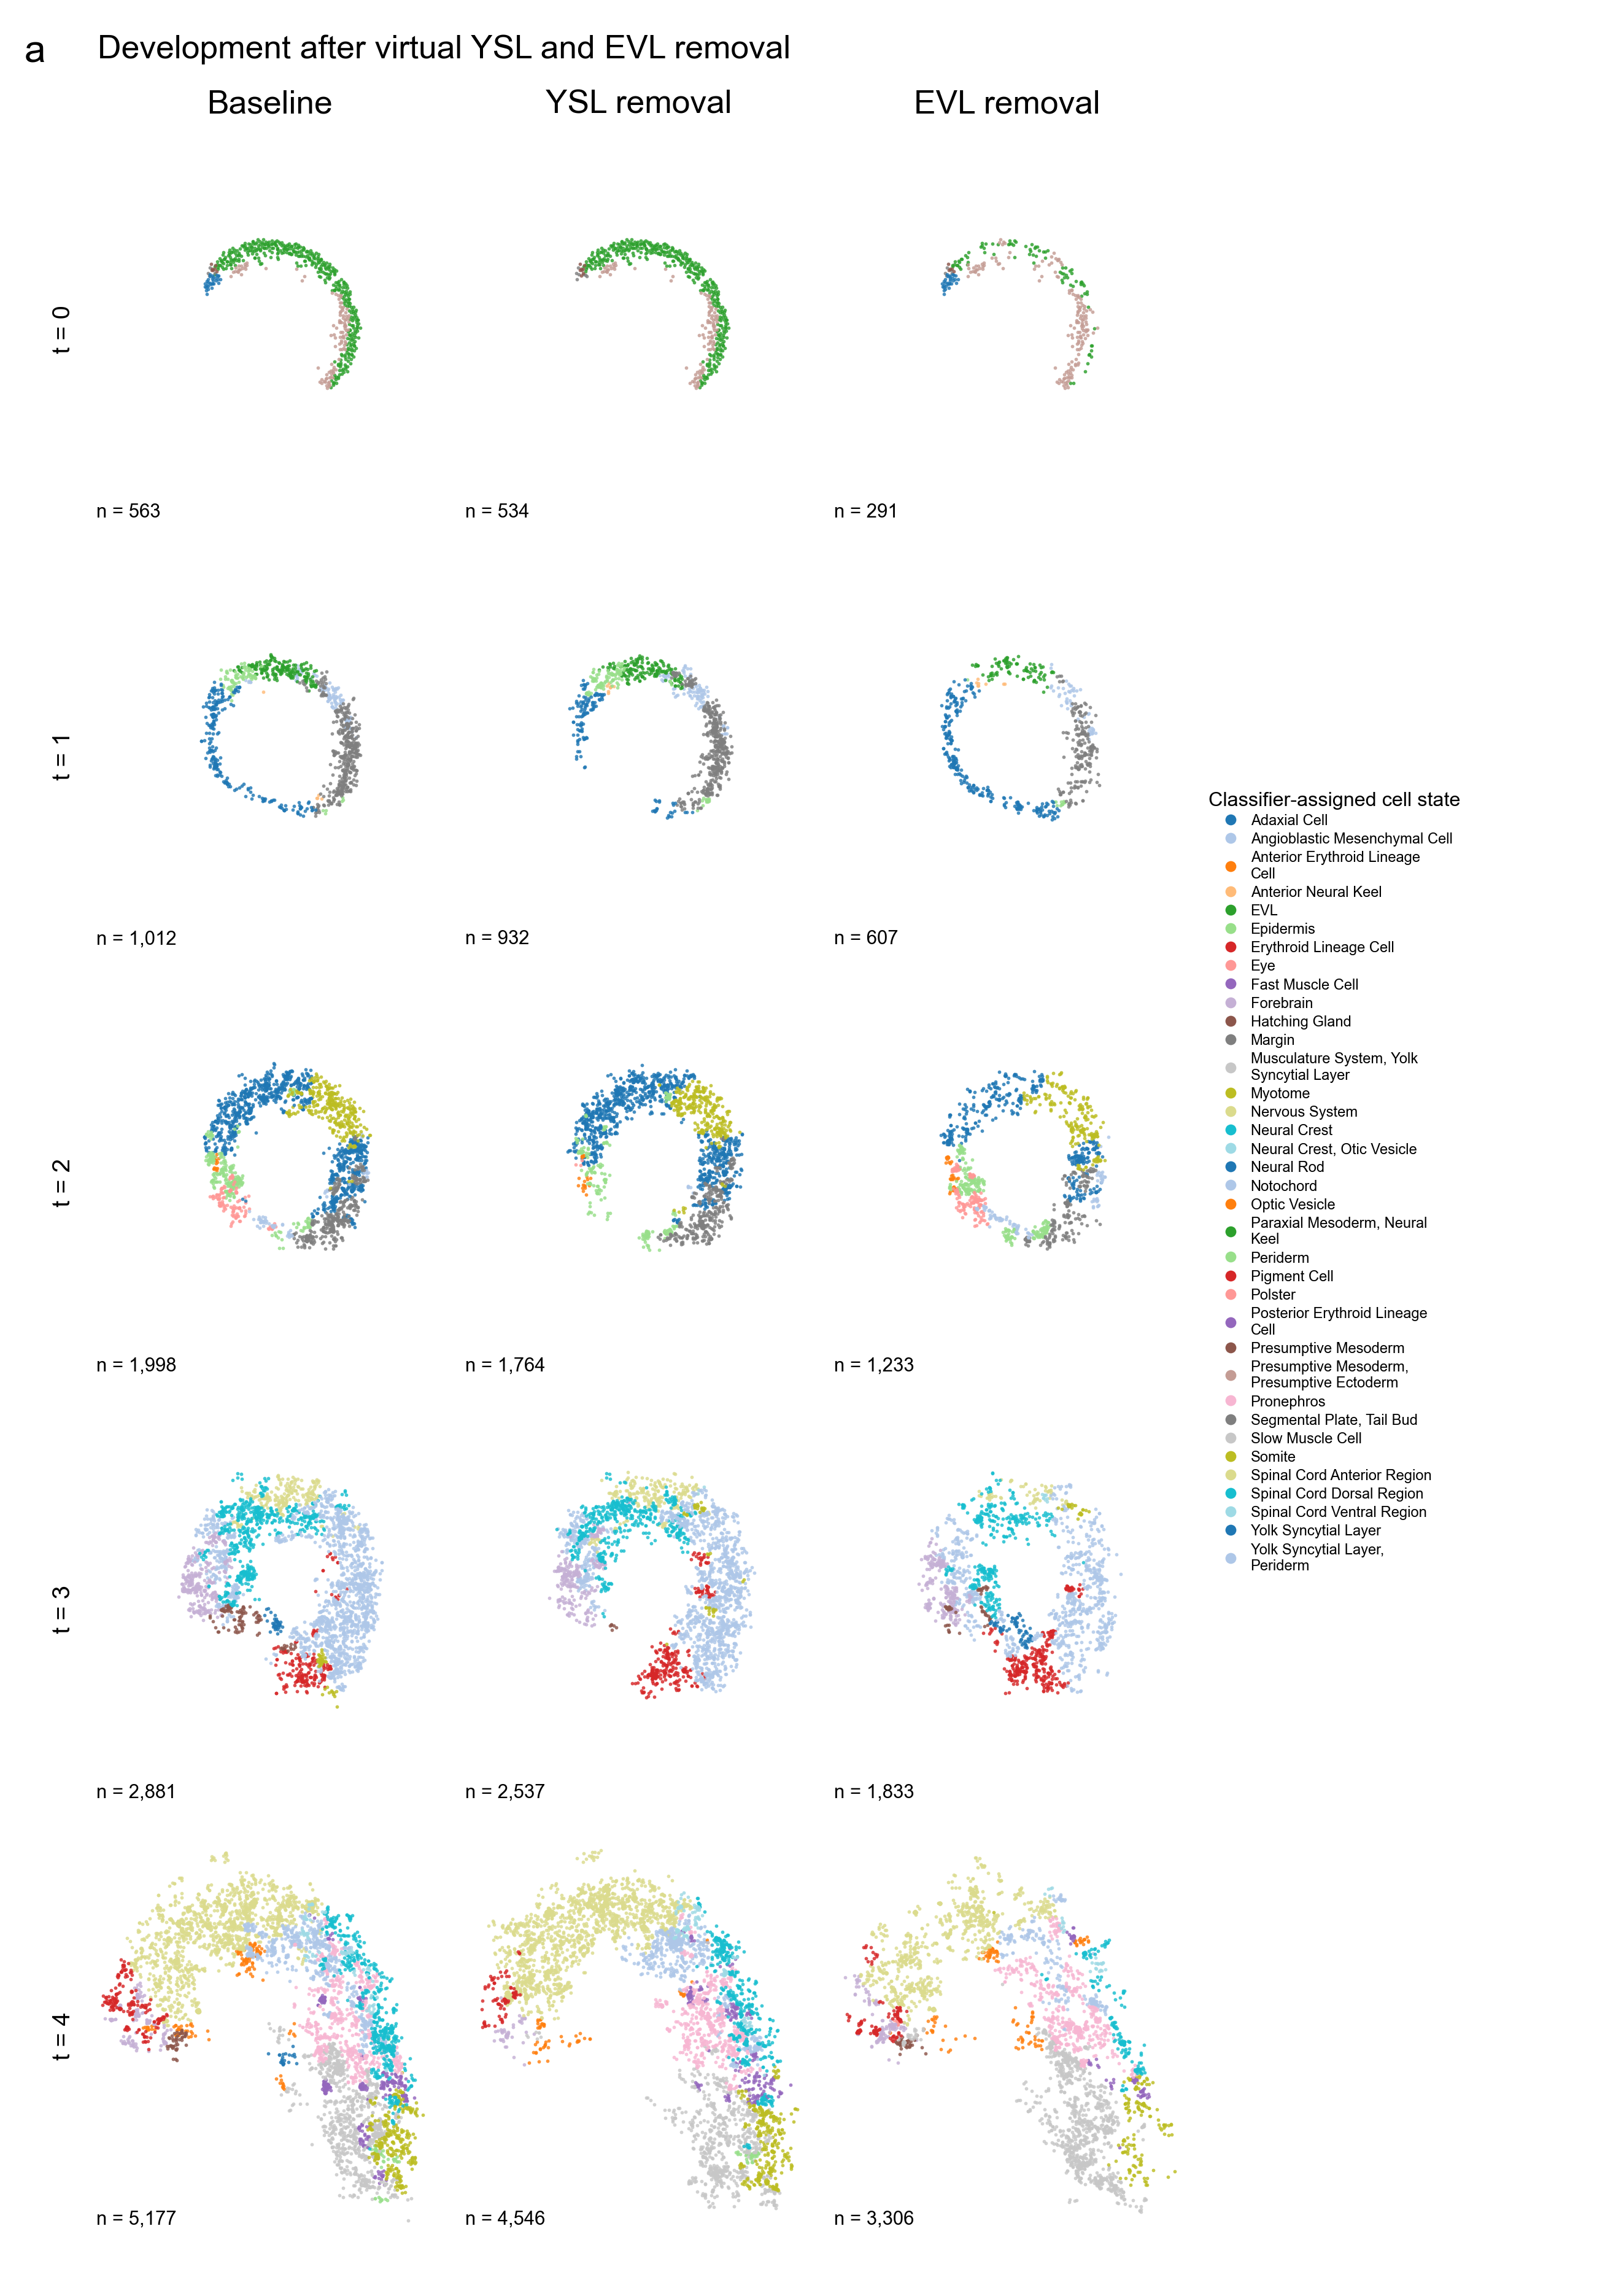

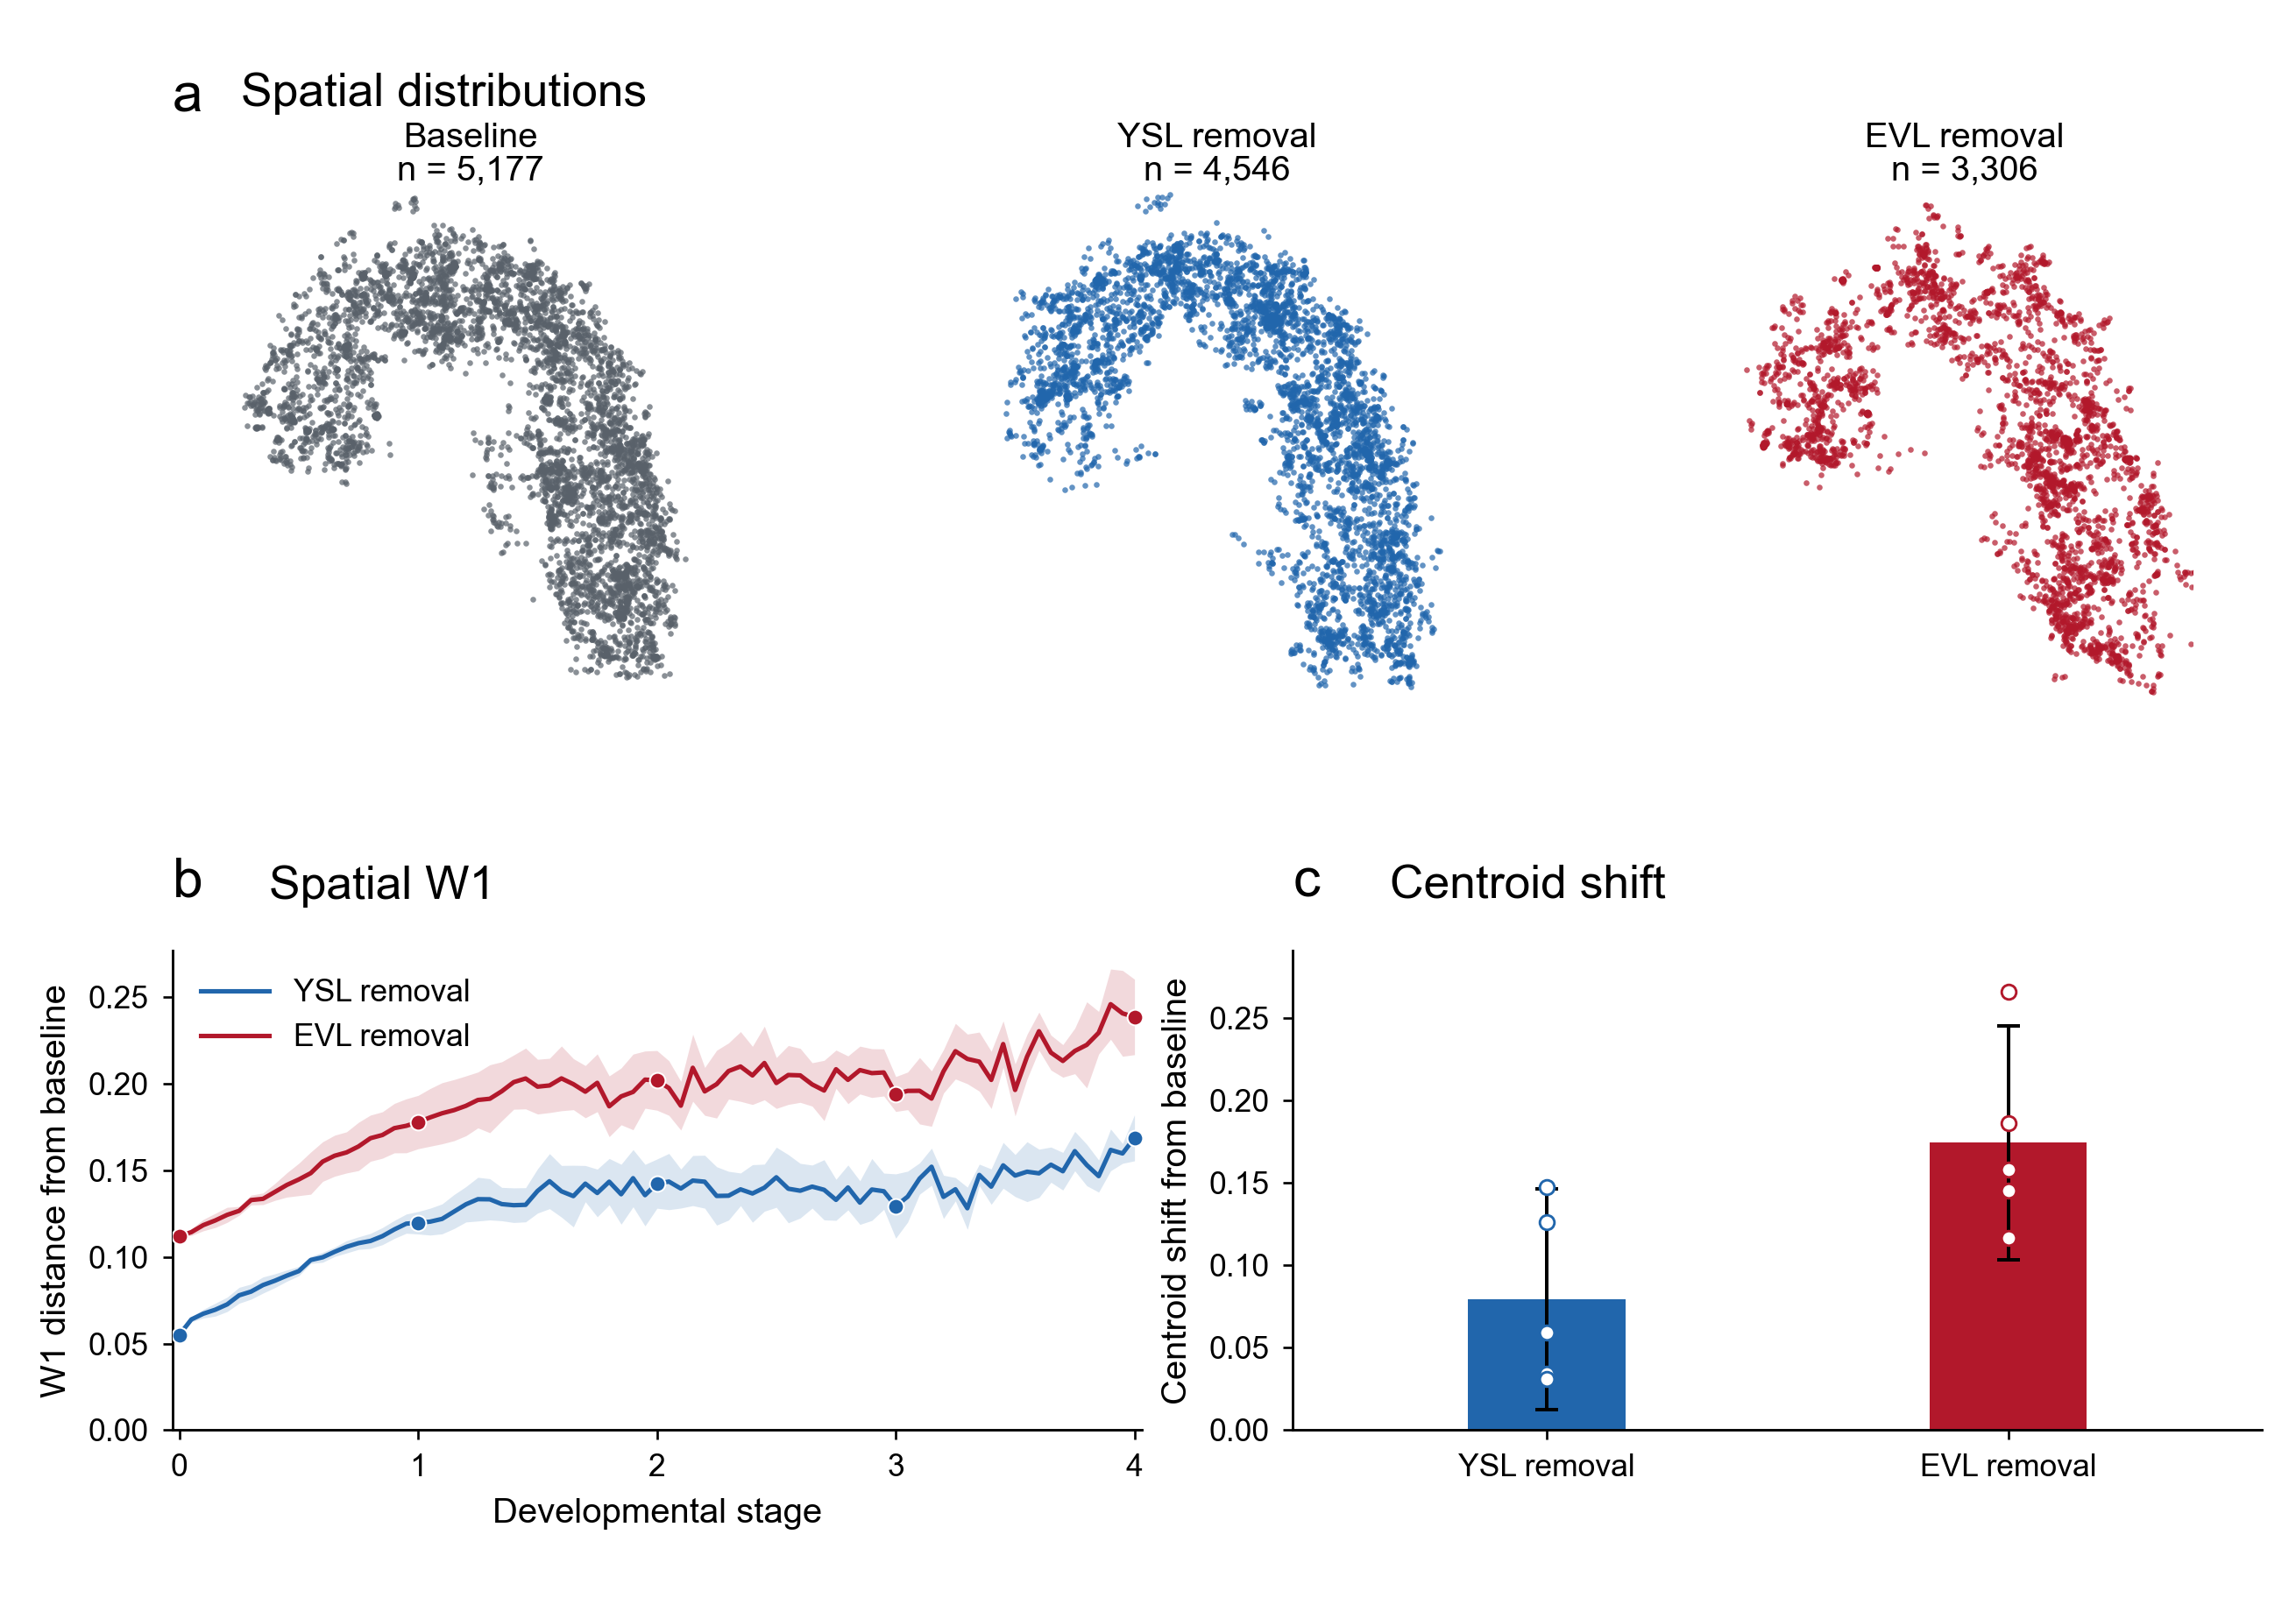

In [6]:
from reproduction.zebrafish.plot_virtual_removal import collect_metrics, draw as plot_removal

_, w1_curve, centroid_values, centroid_summary = collect_metrics(removal_runs)
display(centroid_summary)
removal_figures = plot_removal(data, removal_runs, run / "s33_s34", device=device)
show_figures(removal_figures)

## S35. YSL-lineage gene dynamics

Follow the descendants of the YSL cells observed at time zero. The calculation
uses `cb.tl.simulate_sde_points` for continuous population weights and
`cb.tl.simulate_sde_points_split_from_x0` for a resampled growth trajectory.
For each descendant, the stored PCA loadings and center reconstruct gene
expression. Negative reconstructed values are clipped to zero before averaging
within the lineage.

The 250 genes are selected by their larger temporal variance across the two
growth representations, as in the paper analysis. S35 displays the continuous-
weight trajectory, centered and scaled separately for each gene. The call saves
`lineage_gene_expression.csv`, the selected `temporal_expression.csv`, and
`temporal_zscores.csv` before drawing the heat maps.

,0.0,0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0
gene,,,,,,,,,
ACTC1,0.040568,0.021485,0.011135,0.017812,0.046952,0.087552,0.108544,0.096583,0.051924
AL935186.2,0.814551,0.294726,0.113580,0.089161,0.111614,0.143104,0.154995,0.149839,0.128767
BX470229.1,0.117324,0.067530,0.041735,0.029968,0.027499,0.028598,0.028078,0.025427,0.021459
CABZ01021592.1,0.007343,0.011008,0.020974,0.048571,0.088486,0.108483,0.130463,0.188635,0.271068
CR383676.2,0.623128,0.519082,0.388199,0.320370,0.349018,0.452890,0.659817,0.950935,1.276040


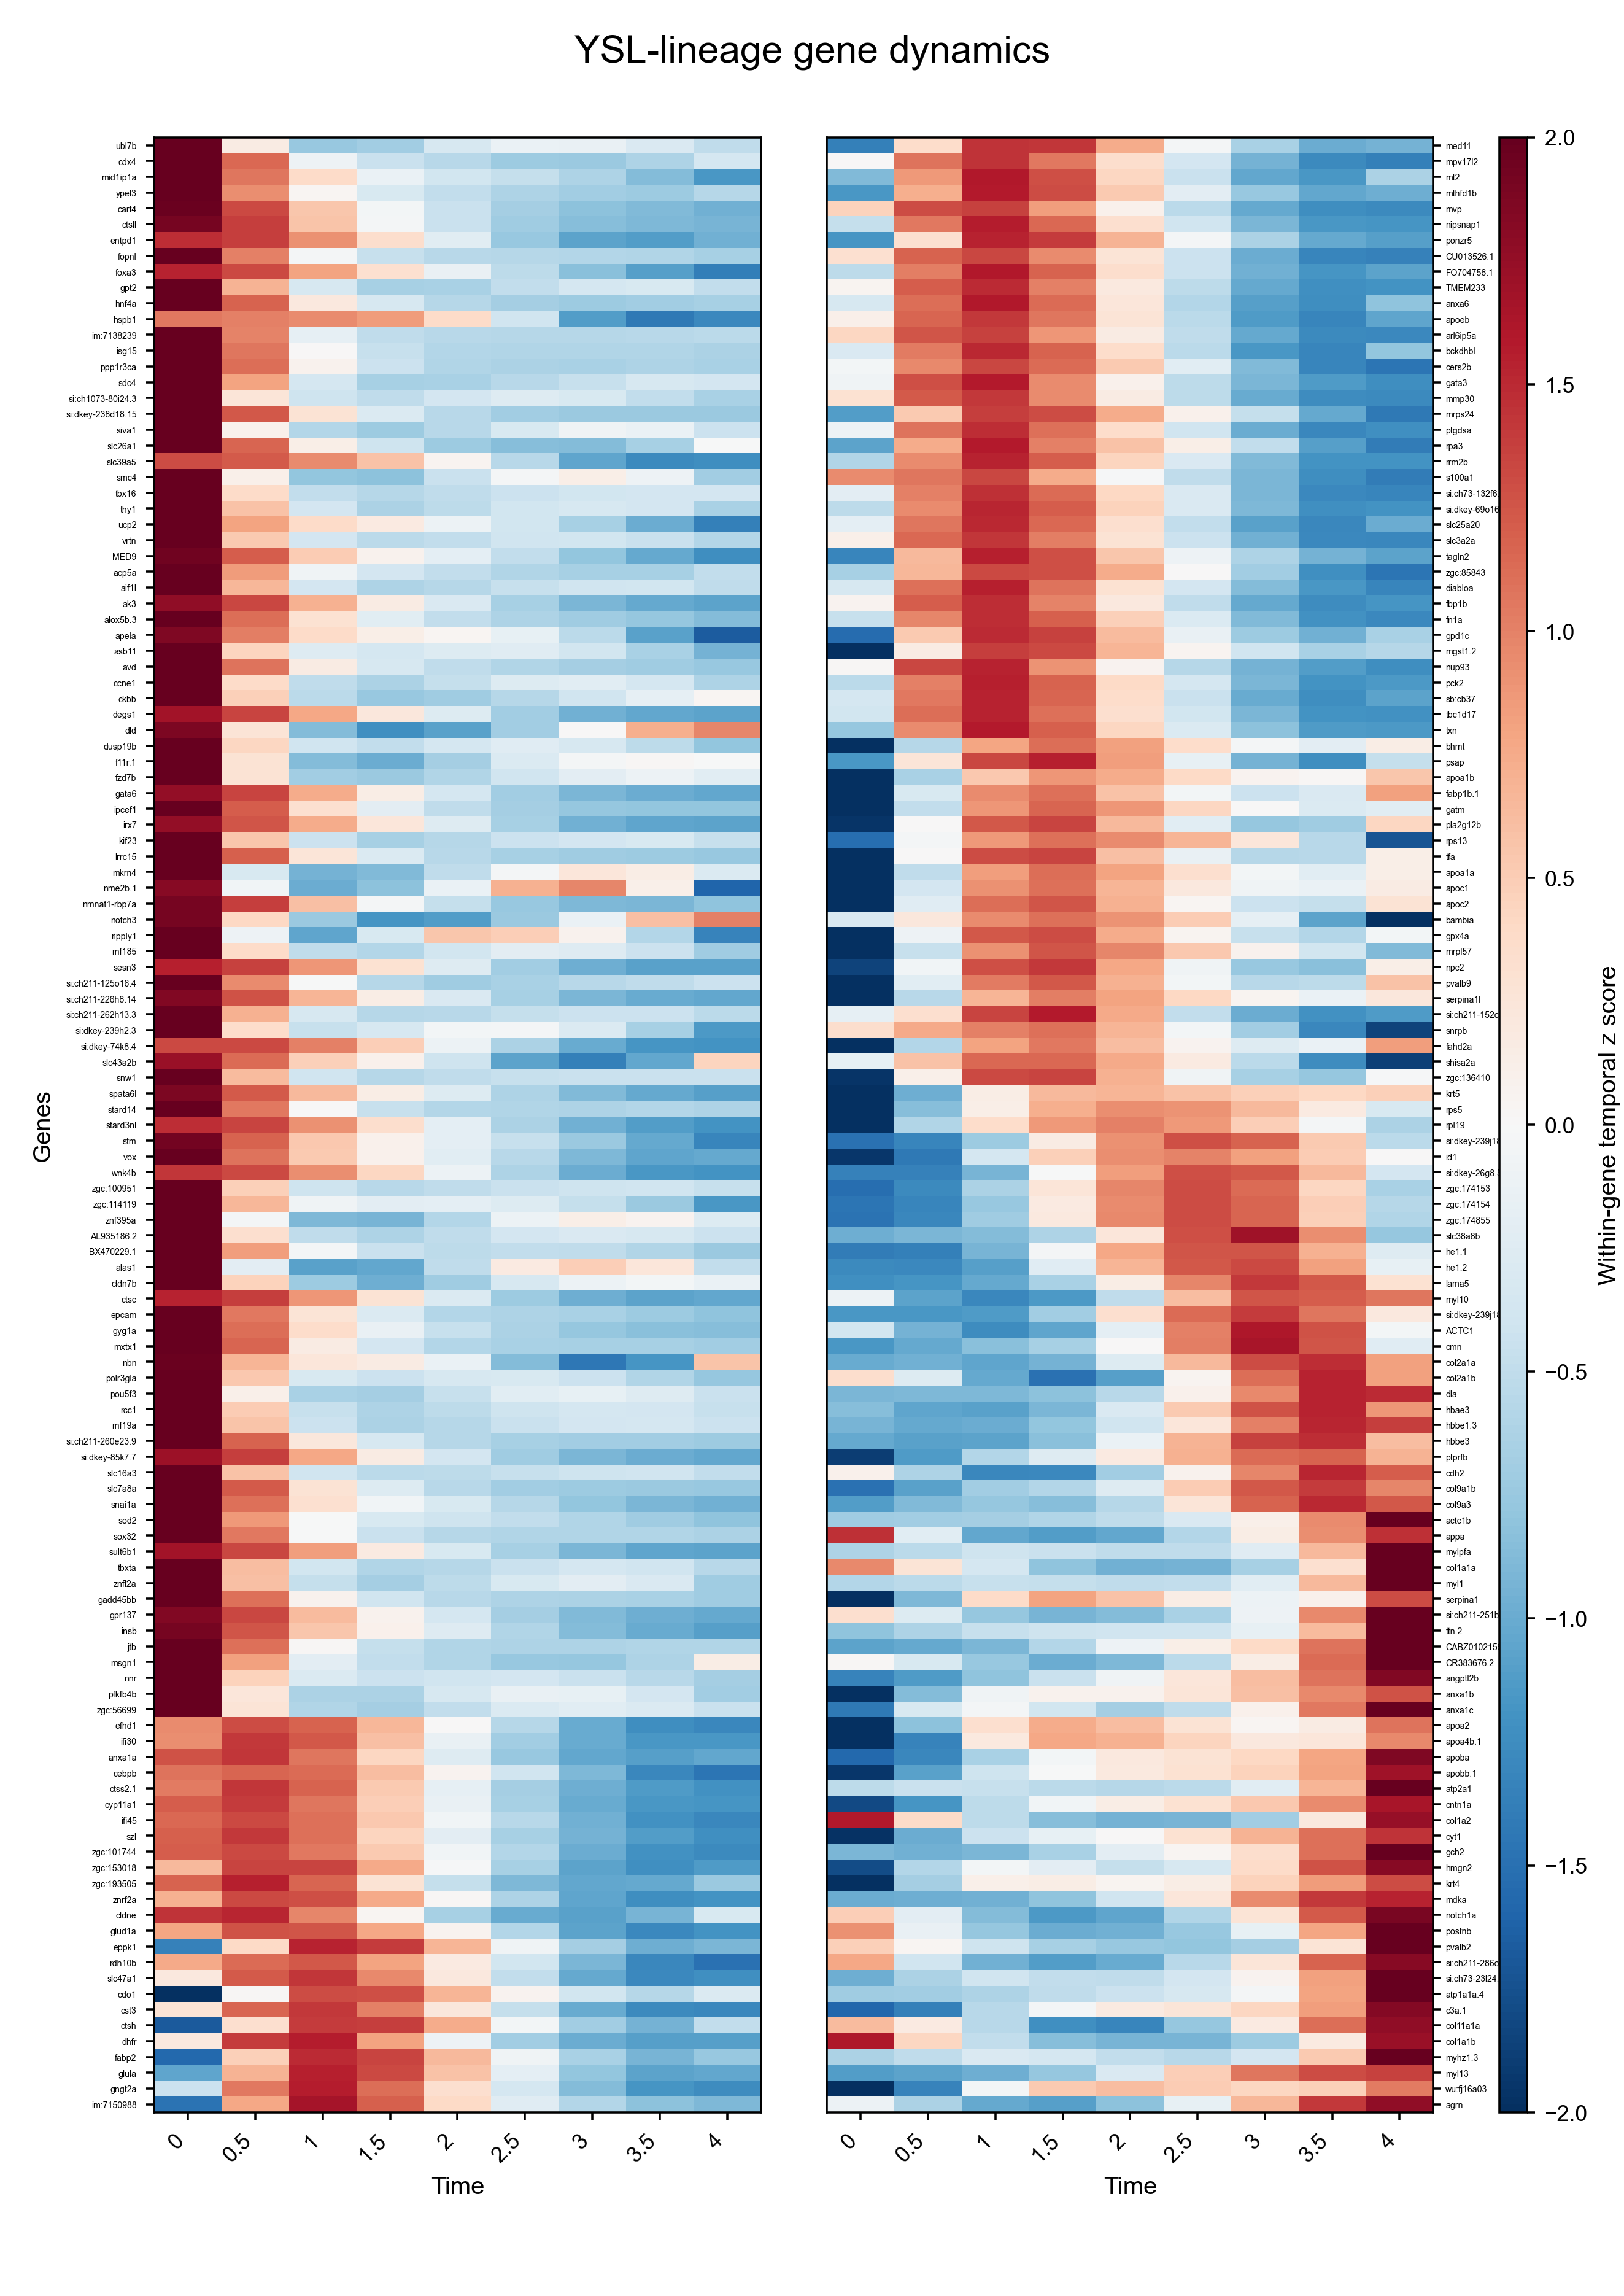

In [7]:
from reproduction.zebrafish.ysl_gene_dynamics import run as calculate_ysl_genes

ysl_figures = calculate_ysl_genes(data, run / "s35", seed=42, device=device, model_dir=model_dir)
display(pd.read_csv(run / "s35/temporal_expression.csv", index_col=0).head())
show_figures(ysl_figures)

## S36. Training-loss comparison

This comparison requires four separately trained models. To draw the recorded
paper results, leave `retrain_loss_models = False`. The cell then reads the
included **numerical evaluation table**, not an image.

To repeat training and evaluation, set `retrain_loss_models = True`. The code
writes four configurations, trains each model on the same aligned cells with
`cytobridge workflow`, and evaluates its generated distributions with
`cb.tl.evaluate_model_distributions`. Each evaluation writes
`distribution_metrics.csv` and `distribution_samples.npz`. The resulting
tables replace the included table in `loss_metrics` and feed the same plot.
The edge predictor's `.meta.json` file supplies its fitted decision threshold.

In [8]:
from scripts.paper_figures.zebrafish_loss_weight.collect_alpha_metrics import collect as collect_expression_weights
from scripts.paper_figures.zebrafish_loss_weight.plot_figure import load_results as collect_loss_metrics

if retrain_loss_models:
    loss_scripts = code_dir / "scripts/paper_figures/zebrafish_loss_weight"
    configs = run / "loss_configs"
    evaluations = run / "loss_evaluations"
    run_command([
        sys.executable, loss_scripts / "prepare_configs.py",
        "--base-config", code_dir / "CytoBridge/configs/zebrafish_spatial_full_alpha_express_0015.yaml",
        "--output-dir", configs,
    ], "loss_configurations")
    for condition in ["reference", "alpha_expr_005", "ot_mass_10_to_1", "ot_mass_1_to_10"]:
        training_output = run / "loss_models" / condition
        run_command([
            sys.executable, "-m", "CytoBridge.cli", "workflow", "--config", "zebrafish",
            "--step", "train", "--train", "--aligned-h5ad", data / "aligned.h5ad",
            "--training-config", configs / f"{condition}.yaml",
            "--edge-predictor-path", data / "edge_classifier/zebrafish_edge_model.pt",
            "--output-dir", training_output, "--device", device,
        ], f"train_{condition}")
        run_command([
            sys.executable, loss_scripts / "evaluate_model.py",
            "--aligned-h5ad", data / "aligned.h5ad", "--training-dir", training_output / "training",
            "--condition", condition, "--output-dir", evaluations / condition, "--device", device,
        ], f"evaluate_{condition}")
    alpha_metrics = collect_expression_weights(
        evaluations / "reference/distribution_metrics.csv",
        evaluations / "alpha_expr_005/distribution_metrics.csv",
    )
    alpha_path = evaluations / "alpha_metrics.csv"
    alpha_metrics.to_csv(alpha_path, index=False)
    loss_metrics = collect_loss_metrics(alpha_path, evaluations)
else:
    loss_metrics = pd.read_csv(code_dir / "CytoBridge/results/data/zebrafish_si/s32_loss_weight_metrics.csv")

loss_metrics.head()

,time,space,w1,condition
0,1.0,joint,3.995616,formal_alpha_control
1,1.0,spatial,0.038582,formal_alpha_control
2,1.0,pca,3.925911,formal_alpha_control
3,2.0,joint,4.293041,formal_alpha_control
4,2.0,spatial,0.061544,formal_alpha_control


Each bar in the current S36 figure is a W1 distance at one observed time, in
joint state, expression state, or physical space. The plot reads `loss_metrics`
directly. It also saves `mean_w1.csv`, which averages times 1–4 for each model
setting and output space.

,condition,space,mean_w1
0,formal_alpha_control,joint,4.048724
1,formal_alpha_control,spatial,0.068076
2,formal_alpha_control,pca,3.960879
3,alpha_expr_005,joint,3.694467
4,alpha_expr_005,spatial,0.085292
5,alpha_expr_005,pca,3.628251
6,formal,joint,4.127926
7,formal,spatial,0.065187
8,formal,pca,4.042511
9,ot_mass_10_to_1,joint,4.171453


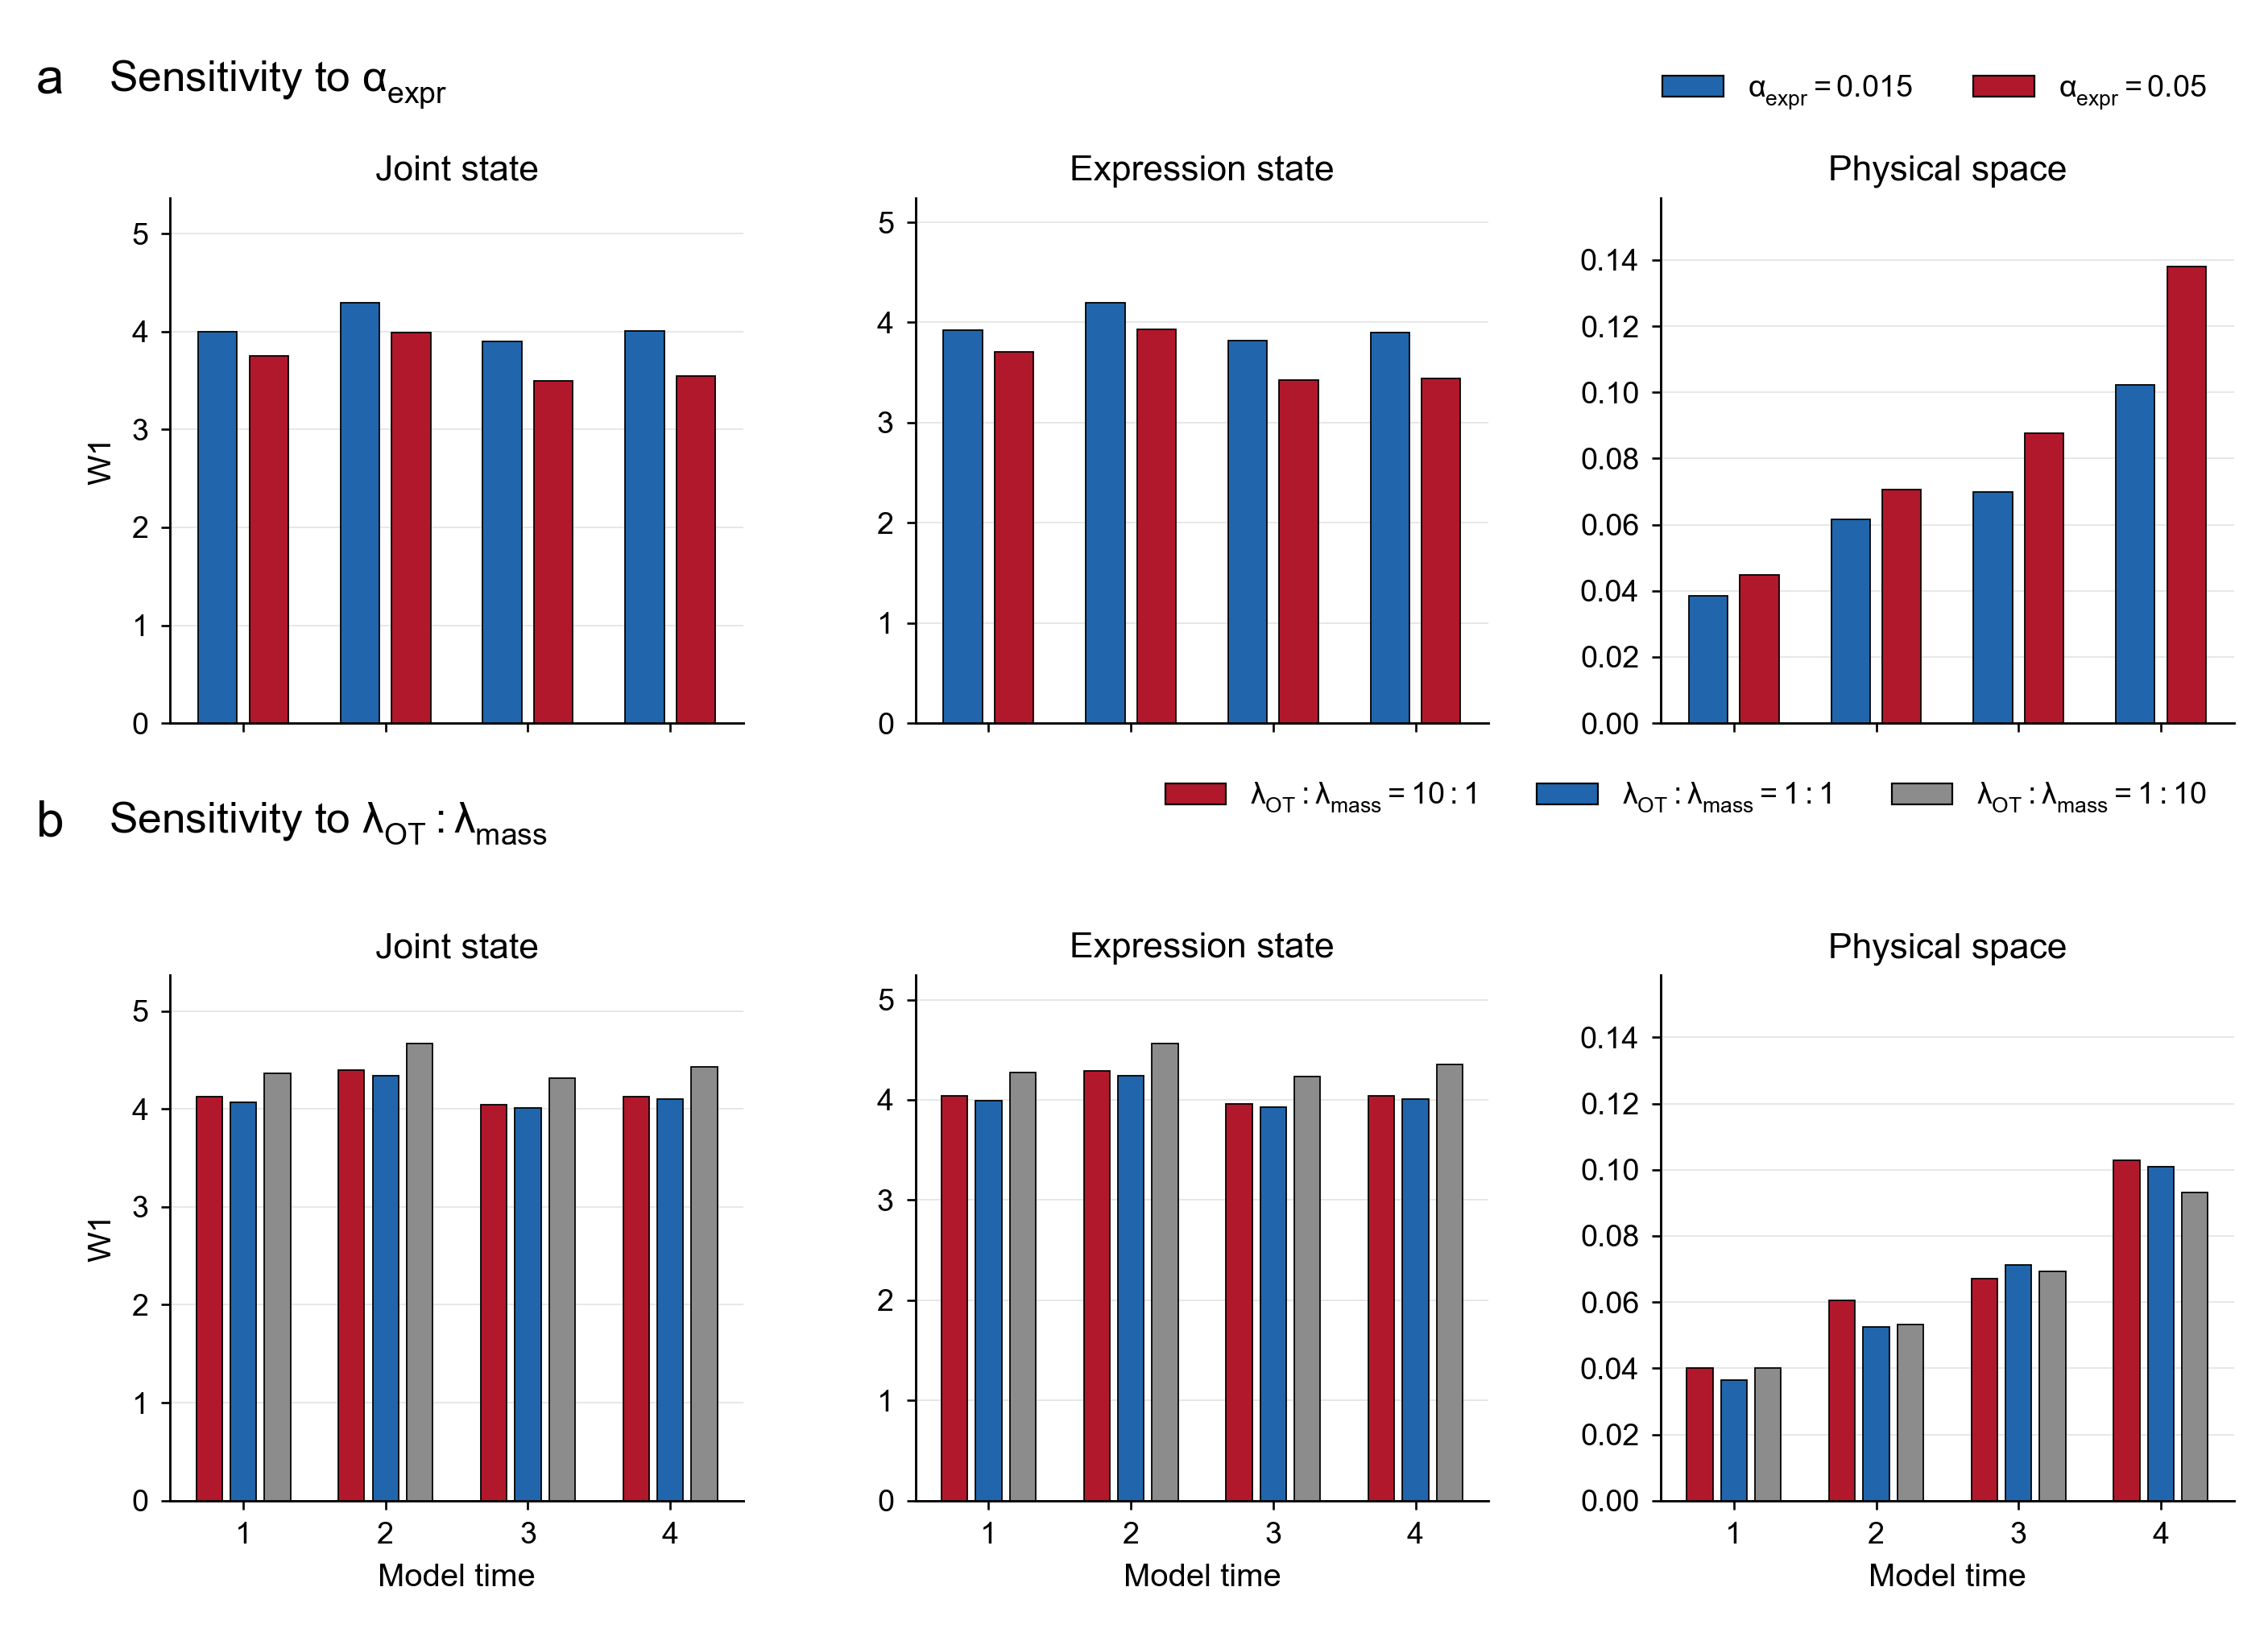

In [9]:
from CytoBridge.results._zebrafish_loss import draw as plot_loss_weights

loss_figures = plot_loss_weights(loss_metrics, run / "s36")
display(pd.read_csv(run / "s36/mean_w1.csv"))
show_figures(loss_figures)

## S37. Daughter-cell perturbations

Each call simulates four perturbation scales, 0, 0.01, 0.03 and 0.06, using
`cb.tl.simulate_sde_points_split_from_x0`. The same time-zero cells are followed
to time four, with lineage IDs retained during growth. The classifier assigns
cell types at each displayed time. The outputs contain cell-type counts,
source-to-target lineage counts, and population sizes.

In [10]:
from reproduction.zebrafish.daughter_noise import simulate as simulate_daughter_perturbations

daughter_runs = []
for seed in seeds:
    folder = run / "daughter" / f"seed_{seed}"
    simulate_daughter_perturbations(data, folder, seed=seed, device=device, model_dir=model_dir)
    daughter_runs.append(folder)

`collect` reads `composition_long.csv`, `lineage_transition_long.csv`,
`particle_counts.csv` and `observed_composition.csv` from those five run folders.
It calculates composition and lineage differences relative to zero perturbation
and saves the tables. `draw` receives that returned object to calculate means
and standard errors and draw S37. The lineage panel keeps the six pairs shown
in the paper.

,seed,time,daughter_noise_std,composition_tv_from_reference,composition_max_abs_fraction_change,lineage_weighted_tv_from_reference,lineage_max_source_tv_from_reference
0,42,0.0,0.00,0.0,0.0,0.0,0.0
1,42,0.0,0.01,0.0,0.0,0.0,0.0
2,42,0.0,0.03,0.0,0.0,0.0,0.0
3,42,0.0,0.06,0.0,0.0,0.0,0.0
4,42,0.5,0.00,0.0,0.0,0.0,0.0


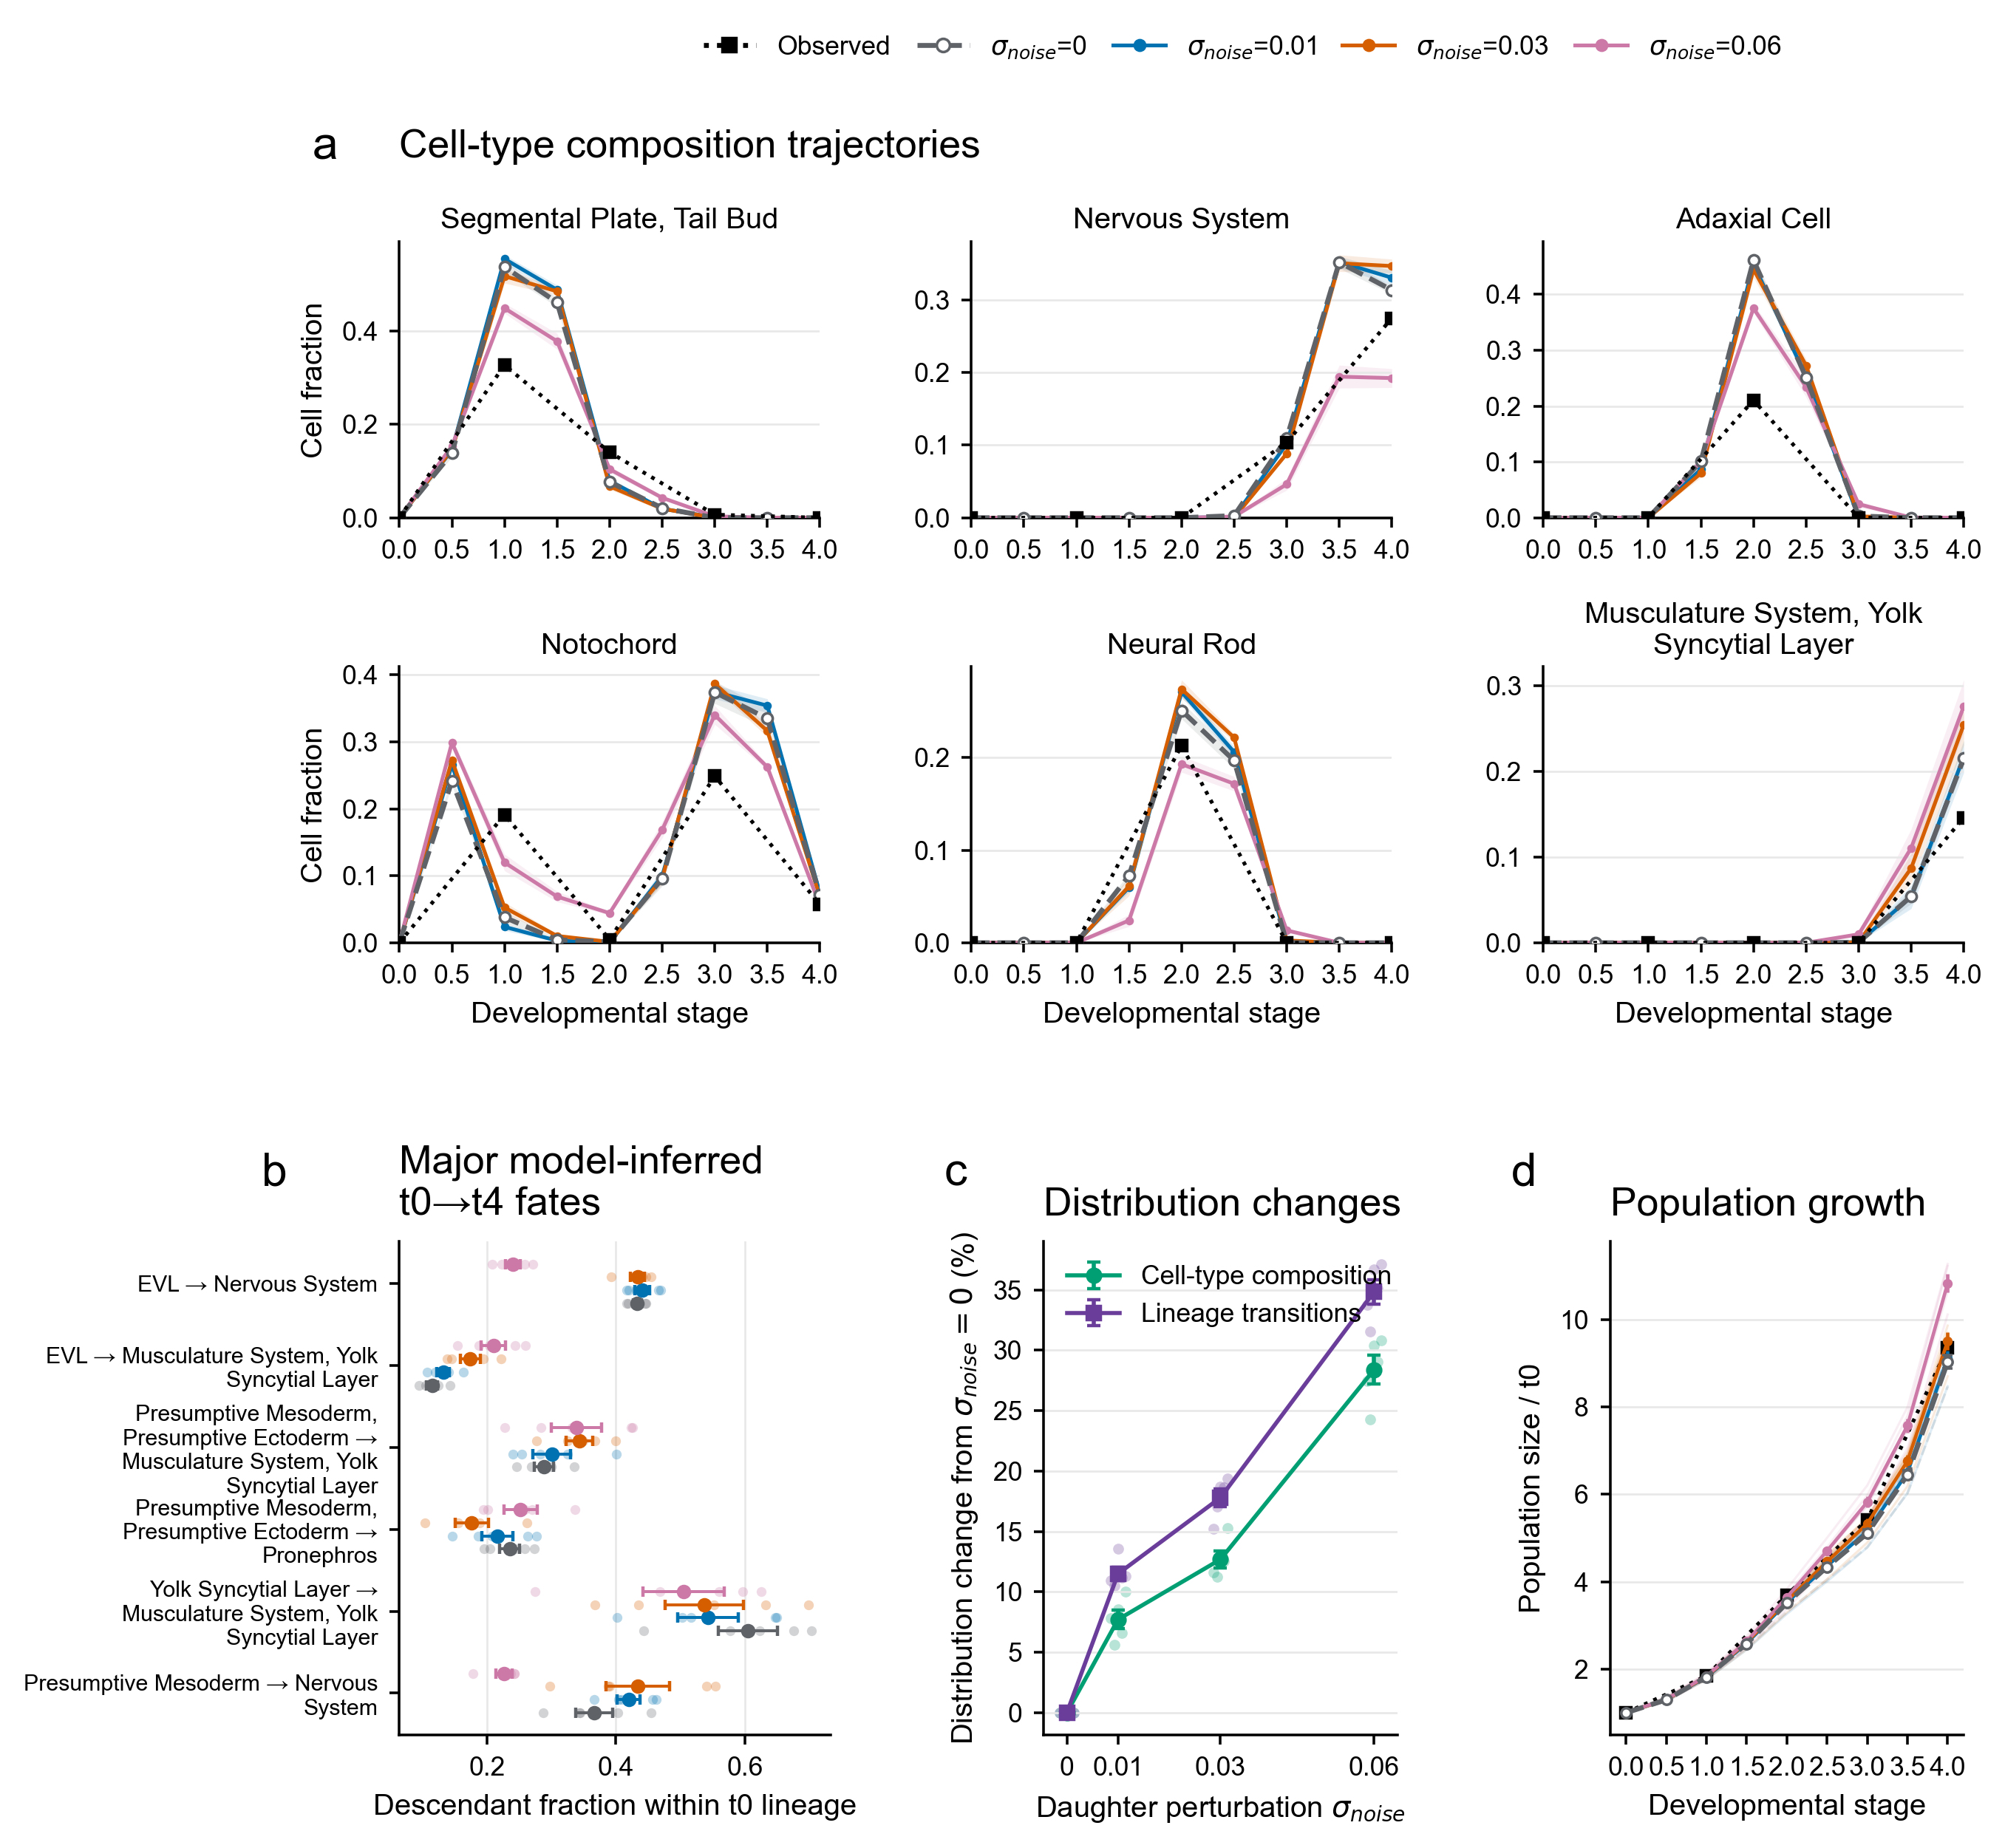

In [11]:
from reproduction.zebrafish.plot_daughter_noise import collect as collect_daughter_results, draw as plot_daughter_results

daughter_tables = collect_daughter_results(daughter_runs, run / "s37")
display(daughter_tables["sensitivity"].head())
daughter_figures = plot_daughter_results(daughter_tables, run / "s37")
show_figures(daughter_figures)

## S38. Gene-expression reconstruction

This comparison uses YSL cells at the observed stages and at simulated half
steps between them. Unlike S35's time-zero lineage, each intermediate population
starts from the preceding observed stage. Cell types at measured times come
from the data, and intermediate cell types come from the classifier.

The `s25` stage calls `cb.tl.summarize_temporal_gene_patterns` to reconstruct
expression from PCs, clip negative values, calculate mean expression, and
select 250 temporally variable genes. It also calculates observed YSL expression
means for the reconstruction comparison.

In [12]:
run_command([
    sys.executable, code_dir / "scripts/run_zebrafish_paper_downstream.py",
    "--aligned-h5ad", data / "aligned.h5ad", "--model-dir", model_dir,
    "--output-dir", model_results, "--shared-cache-dir", run / "classifier_cache",
    "--stage", "s25", "--calculate-only", "--video-formats", "none", "--device", device,
], "gene_reconstruction")

gene_means = pd.read_csv(model_results / "s25/mean_inverse_pca_log1p_clipped.csv", index_col=0)
gene_means.head()

,0.0,0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0
AL935186.2,0.814551,0.348246,0.111785,0.062329,0.105287,0.111242,0.062138,0.075657,0.043156
BX546453.2,0.005556,0.004272,0.003341,0.003092,0.001518,0.001352,0.002685,0.003190,0.001735
CR383676.2,0.623128,0.453822,0.265362,0.246920,0.457575,0.781148,0.738277,0.962859,1.327885
CU467042.1,0.000210,0.001168,0.002565,0.003160,0.003935,0.004385,0.002318,0.002392,0.005512
MEPCE,0.012143,0.018462,0.025726,0.034876,0.058137,0.078868,0.055457,0.055457,0.059038


The plotter reads the new `mean_inverse_pca_log1p_clipped.csv`,
`observed_exact_log1p_anchors.csv` and `top_variable_genes.csv` from `model_results`.
It calculates reconstruction correlations and errors, saves the compared
expression matrices and `reconstruction_metrics.csv`, then draws S38.

,time,n_features,rmse,mae,mean_bias,pearson_r
0,0.0,2584,0.059028,0.020363,0.000637,0.889881
1,1.0,2584,0.012242,0.005888,0.002764,0.995996
2,2.0,2584,0.014797,0.006460,0.002046,0.992598
3,3.0,2584,0.033950,0.011706,0.001930,0.979983
4,4.0,2584,0.024862,0.009095,0.002458,0.993366


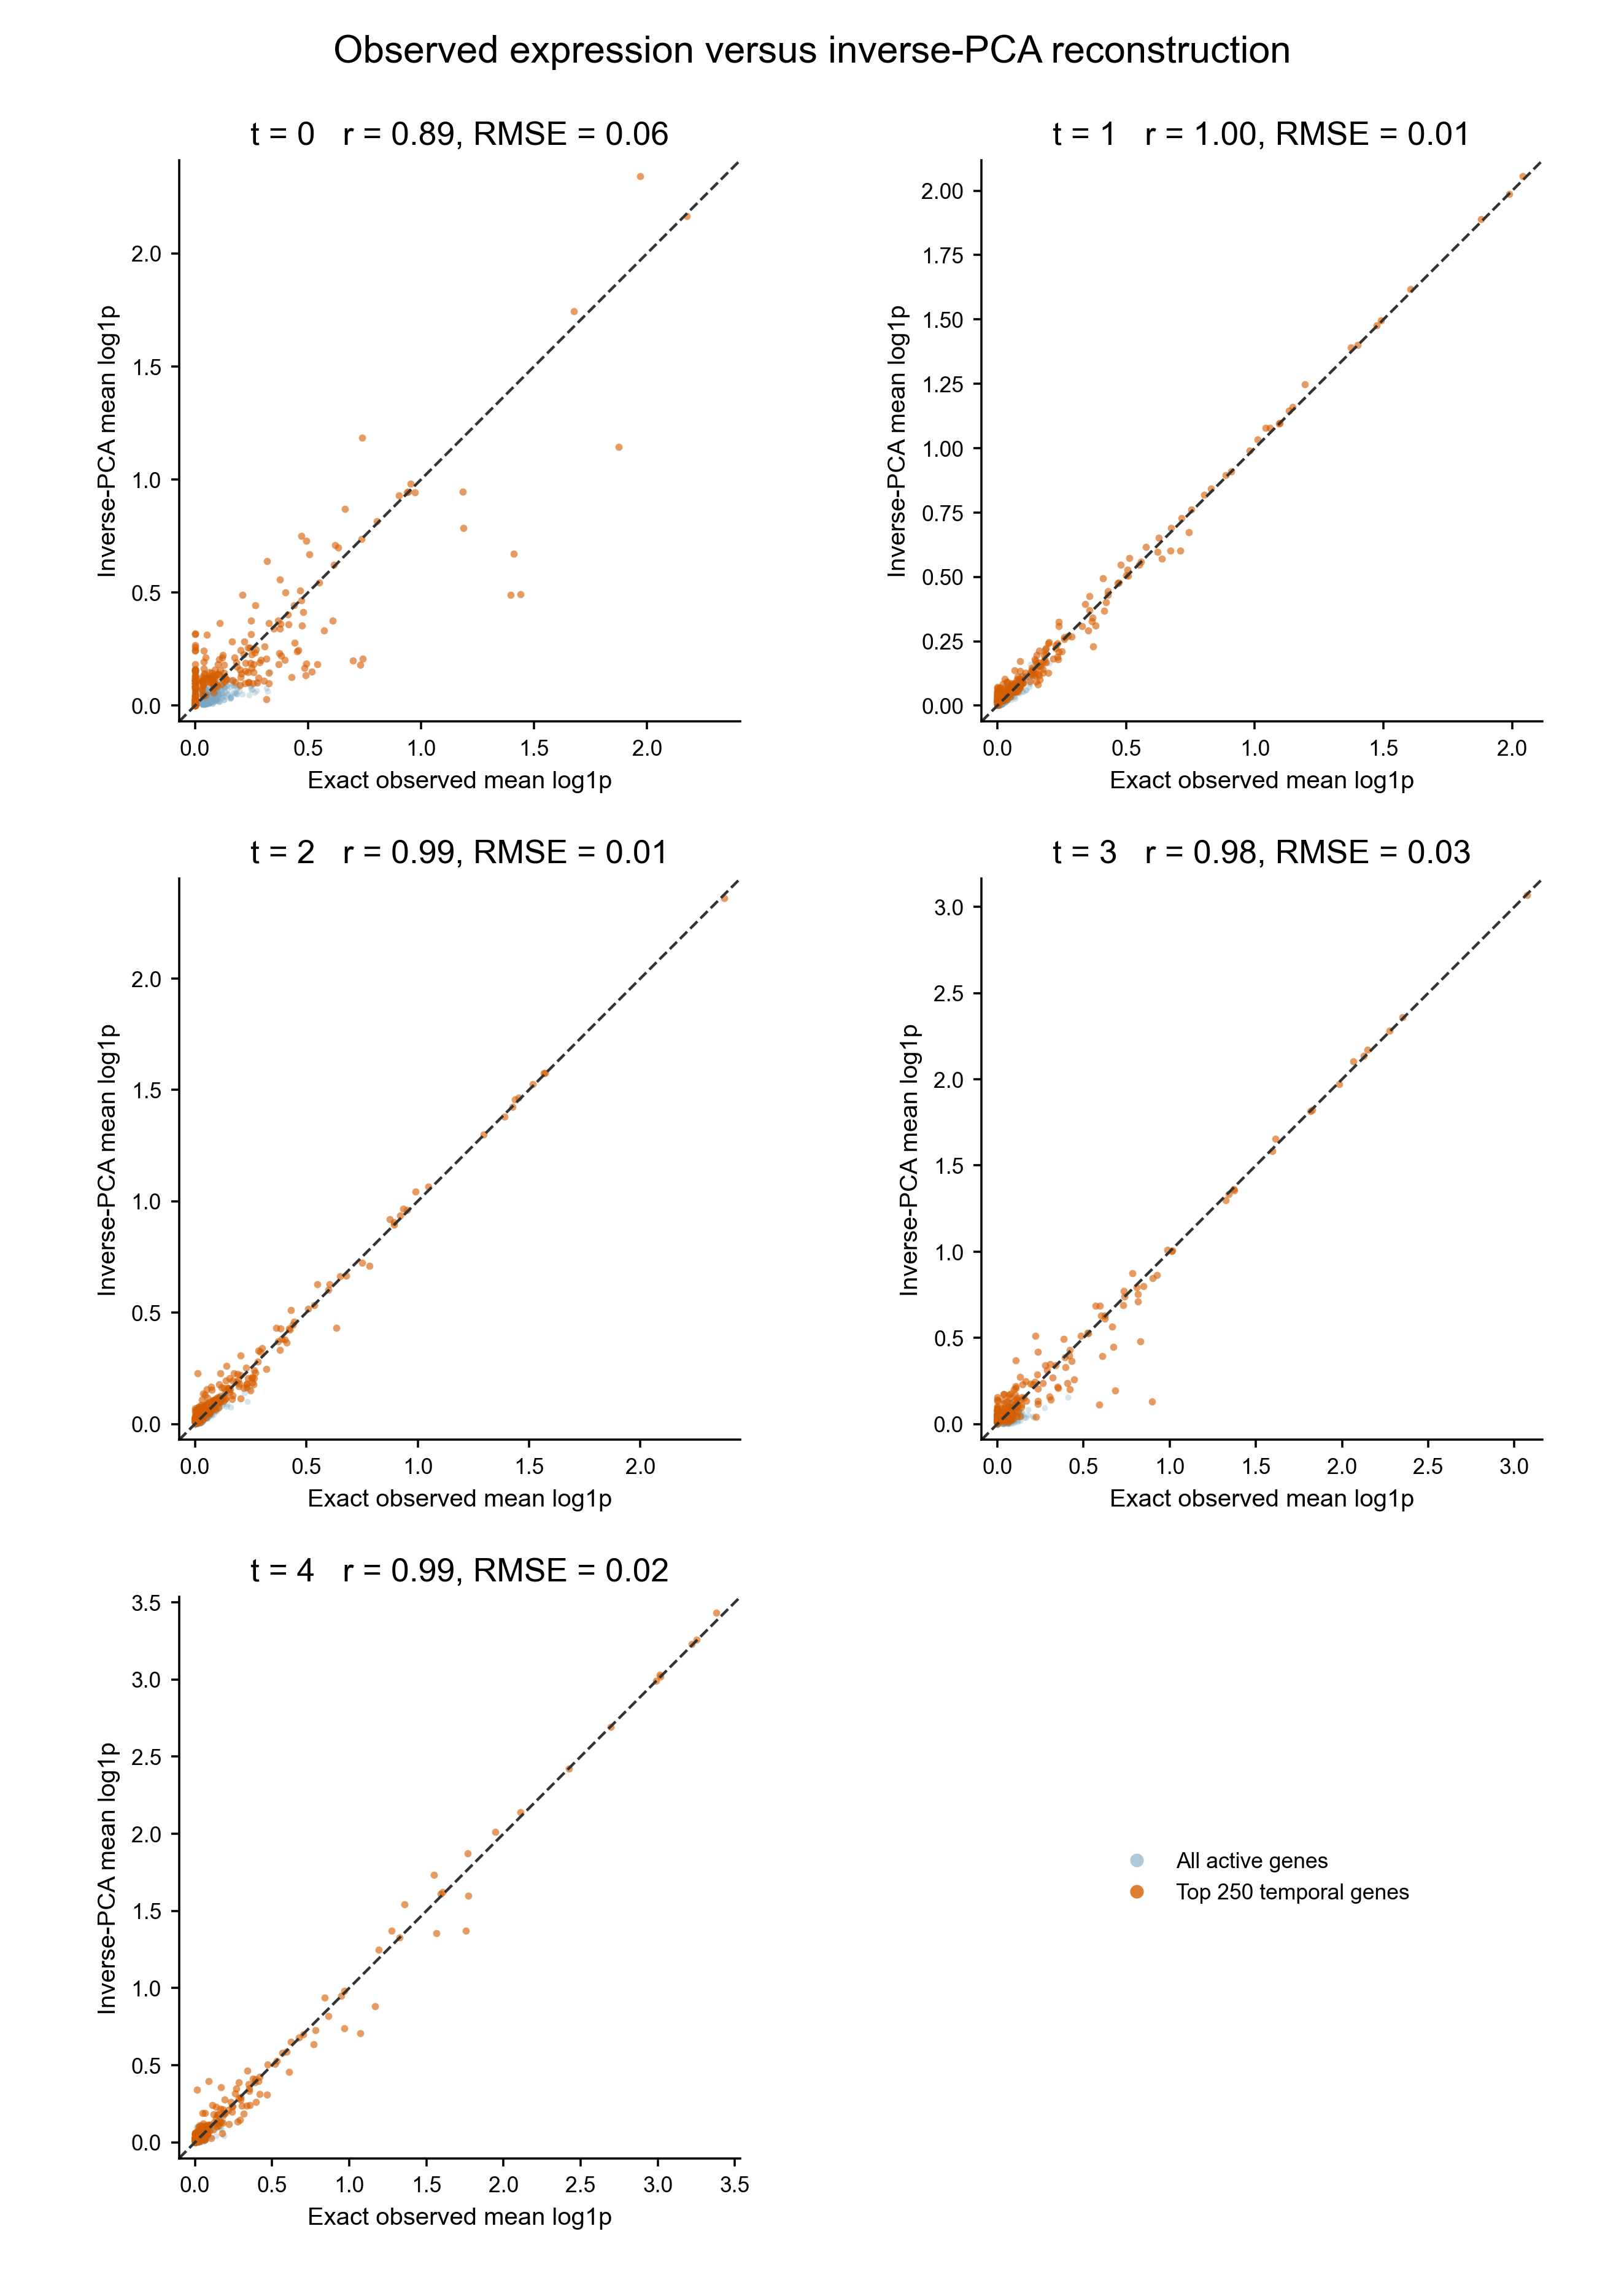

In [13]:
from reproduction.zebrafish.plot_gene_dynamics import draw as plot_gene_reconstruction

reconstruction_figures = plot_gene_reconstruction(model_results, run / "s38")
display(pd.read_csv(run / "s38/reconstruction_metrics.csv"))
show_figures(reconstruction_figures)